# Credit Card Fraud Detection

In [67]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from credit_fraud_pack.pipeline import build_model_pipeline
from credit_fraud_pack.evaluate import evaluate_classifier, plot_confusion_matrix
from credit_fraud_pack.data import load_raw_data
from credit_fraud_pack.config import (PCA_COLS,
                                      FEATURE_COLS,
                                      TARGET_COL,
                                      RANDOM_SEED,
                                      TEST_SIZE)

In [68]:
# Visualisations style variables
COLOR_LEGIT = "#0072B2"
COLOR_FRAUD = "#D55E00"
CLASS_PALETTE = {0: COLOR_LEGIT, 1: COLOR_FRAUD}

sns.set_theme(style="whitegrid")
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", 35)
pd.set_option("display.width", 120)

## Load Data

In [69]:
# Load raw data
df = load_raw_data()
df.shape

(284807, 31)

In [70]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

All 31 features in the dataset are numeric and the dataset takes up about 67.4 MBs, which is small enough to work with in pandas without chunking. There is no mix of data types that need cleaning.

In [72]:
# Check for missing values
num_missing = df.isnull().sum().sum()
print(f"Total missing values: {num_missing}")

Total missing values: 0


In [73]:
# Check for duplicates
num_duplicates = df.duplicated().sum()
duplicate_share = num_duplicates / len(df)
print(f"Exact duplicate rows: {num_duplicates} ({duplicate_share:.3%} of the data)")

Exact duplicate rows: 1081 (0.380% of the data)


There are zero missing values, however 1,081 exact duplicate rows (~0.38% of the data). Before dropping any duplicates the class that they fall into will be checked, this is because dropping duplicates will shrink the already small set of fraud data.

In [74]:
print(df.loc[df.duplicated(), "Class"].value_counts())

df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after dropping duplicates: {df.shape}")

Class
0    1062
1      19
Name: count, dtype: int64
Shape after dropping duplicates: (283726, 31)


## Class Balance

In [75]:
class_counts = df["Class"].value_counts().sort_index()
class_pct = df["Class"].value_counts(normalize=True).sort_index() * 100
pd.DataFrame({"count": class_counts, "percent": class_pct.round(3)})

,count,percent
Class,,
0,283253,99.833
1,473,0.167


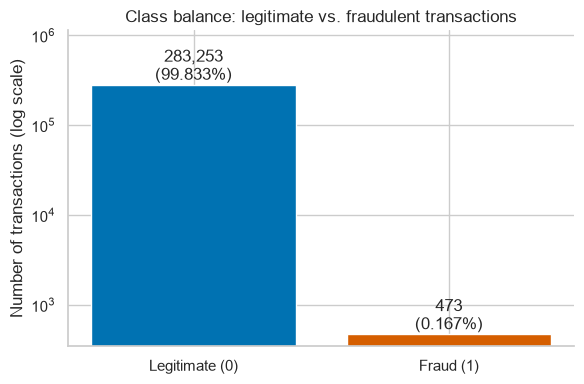

In [76]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Legitimate (0)", "Fraud (1)"], class_counts, color=[COLOR_LEGIT, COLOR_FRAUD])

ax.set_yscale("log")
ax.set_ylabel("Number of transactions (log scale)")
ax.set_title("Class balance: legitimate vs. fraudulent transactions")

for bar, count, pct in zip(bars, class_counts, class_pct):
    ax.annotate(f"{count:,}\n({pct:.3f}%)",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom")

ax.set_ylim(top=class_counts.max() * 4)
plt.tight_layout()
plt.show()

**Observation:** Fraud makes up only 0.167% of transactions (473 out of 283,726), which is about 1 in every 600.

- **Accuracy isn't the most important metric:** A model that always predicts "not fraud" would score 99.8% accuracy while catching zero fraud, so evaluation should rely on precision, recall, F1 and AUPRC instead.
- **The train test split must be stratified on "Class":** A random split could easily leave the test set with too few fraud cases to evaluate against, it could even leave the test set with zero fraud cases.
- **The class imbalance itself needs direct treatment:** Class weighing or resampling such as SMOTE will be used because most classifiers default to optimising overall accuracy and will otherwise learn to mostly ignore the minority class.

## Why `Time` and `Amount` need different treatment from `V1` - `V28`

In [77]:
v_cols = PCA_COLS
scale_summary = df[v_cols + ["Time", "Amount"]].agg(["mean", "std"]).T
scale_summary.round(2)

,mean,std
V1,0.01,1.95
V2,-0.00,1.65
V3,0.00,1.51
V4,-0.00,1.41
V5,0.00,1.38
V6,-0.00,1.33
V7,0.00,1.23
V8,-0.00,1.18
V9,-0.00,1.10
V10,-0.00,1.08


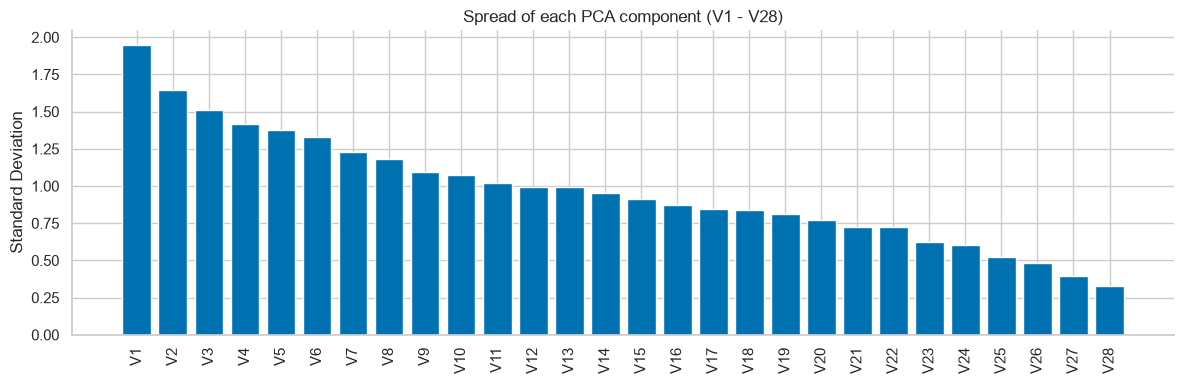

In [78]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(v_cols, df[v_cols].std(), color=COLOR_LEGIT)
ax.set_ylabel("Standard Deviation")
ax.set_title("Spread of each PCA component (V1 - V28)")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

`V1`-`V28` all have a mean near 0 and a standard deviation that is at most a little bit above 1. The standard deviation decreases fairly steadyily from `V1`-`V28`, which makes sense given that the transaction features where already transformed via PCA.

`Time` and `Amount` on the other hand, were not part of the PCA step and sit on completely different scales, with a standard deviation of 47,481 (seconds) and 250, respectively. Distance and gradient based models would let `Time` and `Amount` influence the prediction much more purely because of scale. This is why it is necessary to scale the features using the StandardScaler.

## Transaction amount

In [79]:
df["Amount"].describe()

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

In [80]:
# Same summary, split by class, to see whether fraud looks different
summary_cols = ["count", "mean", "50%", "std", "max"]
df.groupby("Class")["Amount"].describe()[summary_cols]

,count,mean,50%,std,max
Class,,,,,
0,283253.0,88.413575,22.00,250.379023,25691.16
1,473.0,123.871860,9.82,260.211041,2125.87


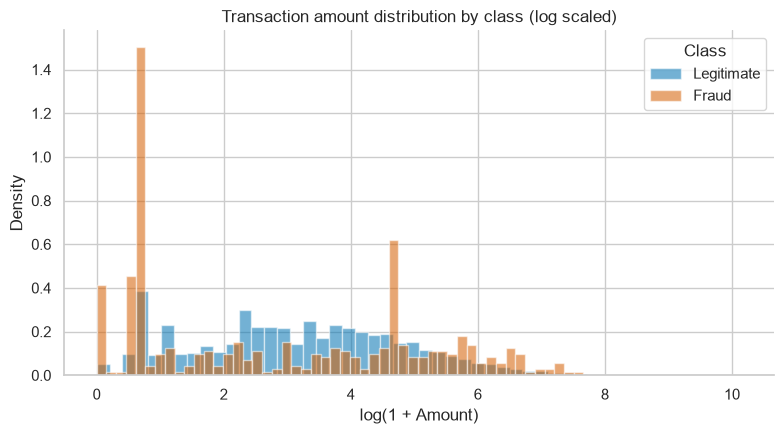

In [81]:
fig, ax = plt.subplots(figsize=(8, 4.5))
class_labels = [(0, COLOR_LEGIT, "Legitimate"), (1, COLOR_FRAUD, "Fraud")]
for cls, color, label in class_labels:
    ax.hist(np.log1p(df.loc[df["Class"] == cls, "Amount"]), bins=50,
            density=True, alpha=0.55, color=color, label=label)

ax.set_xlabel("log(1 + Amount)")
ax.set_ylabel("Density")
ax.set_title("Transaction amount distribution by class (log scaled)")
ax.legend(title="Class")
plt.tight_layout()
plt.show()

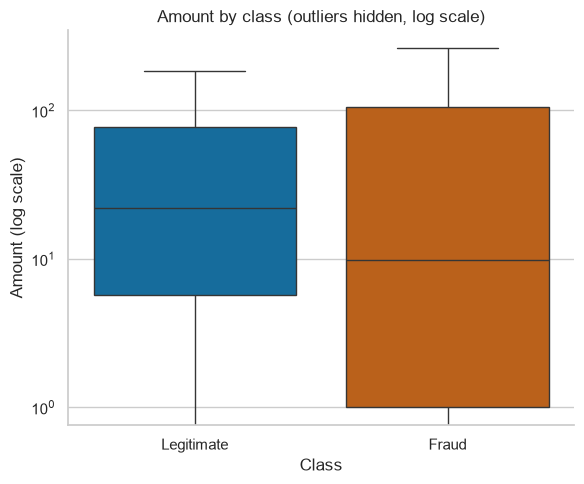

In [82]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=df, x="Class", y="Amount", hue="Class", palette=CLASS_PALETTE,
            showfliers=False, legend=False, ax=ax)

ax.set_yscale("log")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Legitimate", "Fraud"])
ax.set_ylabel("Amount (log scale)")
ax.set_title("Amount by class (outliers hidden, log scale)")
plt.tight_layout()
plt.show()

**Observation:** The median of fraudulent transactions is smaller than the median of the legitimate ones.

## Transaction Timing

In [83]:
# Time in seconds since the first transaction over a 2-day window
df["hour_in_period"] = df["Time"] // 3600       # 0-47
df["hour_of_day"] = df["hour_in_period"] % 24   #0-23, both days combined
df["hour_in_period"].max(), df["hour_of_day"].max()

(np.float64(47.0), np.float64(23.0))

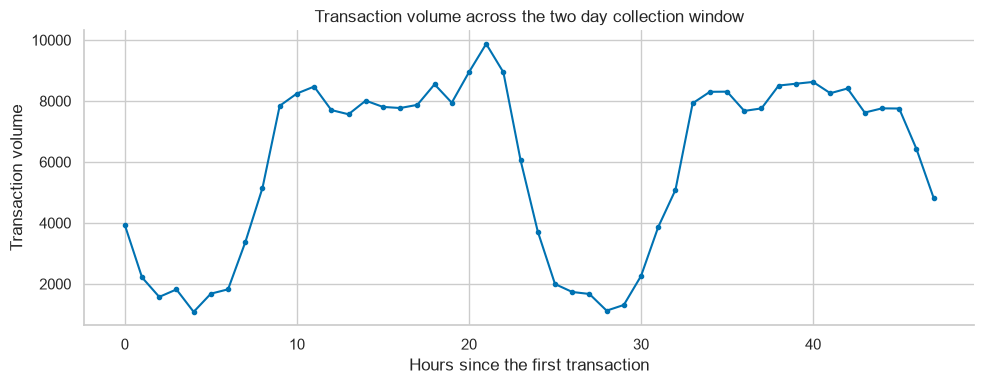

In [84]:
fig, ax = plt.subplots(figsize=(10, 4))
df["hour_in_period"].value_counts().sort_index().plot(
    kind="line", ax=ax, color=COLOR_LEGIT, marker="o", markersize=3
)

ax.set_xlabel("Hours since the first transaction")
ax.set_ylabel("Transaction volume")
ax.set_title("Transaction volume across the two day collection window")
plt.tight_layout()
plt.show()

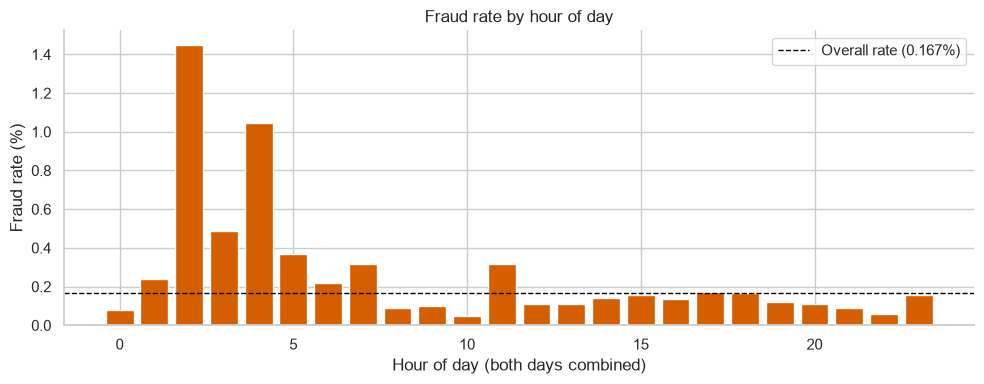

In [85]:
fraud_rate_by_hour = df.groupby("hour_of_day")["Class"].mean() * 100
overall_rate = df["Class"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(fraud_rate_by_hour.index, fraud_rate_by_hour.values, color=COLOR_FRAUD)
ax.axhline(overall_rate, color="black", linewidth=1, linestyle="--",
           label=f"Overall rate ({overall_rate:.3f}%)")

ax.set_xlabel("Hour of day (both days combined)")
ax.set_ylabel("Fraud rate (%)")
ax.set_title("Fraud rate by hour of day")
ax.legend()
plt.tight_layout()
plt.show()

**Observation:** Overall transaction volume shows a clear daily rhythm. It dips twice, once every night. This is expected for genuine cardholder activity. Fraud rate, however spikes overnight, it peaks around 02:00 and stays elevated into the early morning, then settles below the overall rate for most of the daytime hours. This is consistent with fraud being comparatively more common when legitimate transaction volume is at its lowest.

The linear relationship between `Time` and `Class` is negligible, it's approximately -0.012. This can be seen in the next section of this notebook. The chart above shows that the fraud rate varies with the hour of day, so there is a real signal, it's just not linear. Time will be kept as a feature that will be scaled inside the pipeline rather than dropped. Tree-based models can make use of the overnight pattern and a cyclical encoding of `hour_of_day` is noted as a possible refinement later. The engineered `hour_in_period` / `hour_of_day` columns used in this section are for EDA only and will not be part of the model's feature set.

## Correlation with the fraud label

In [86]:
feature_cols = FEATURE_COLS
corr_with_class = df[feature_cols + ["Class"]].corr()["Class"].drop("Class")
corr_with_class = corr_with_class.sort_values()
corr_with_class.round(3)

V17      -0.313
V14      -0.293
V12      -0.251
V10      -0.207
V16      -0.187
V3       -0.182
V7       -0.172
V18      -0.105
V1       -0.094
V9       -0.094
V5       -0.088
V6       -0.044
Time     -0.012
V24      -0.007
V23      -0.006
V13      -0.004
V15      -0.003
V25       0.003
V26       0.004
V22       0.005
Amount    0.006
V28       0.010
V20       0.021
V27       0.022
V21       0.026
V8        0.033
V19       0.034
V2        0.085
V4        0.129
V11       0.149
Name: Class, dtype: float64

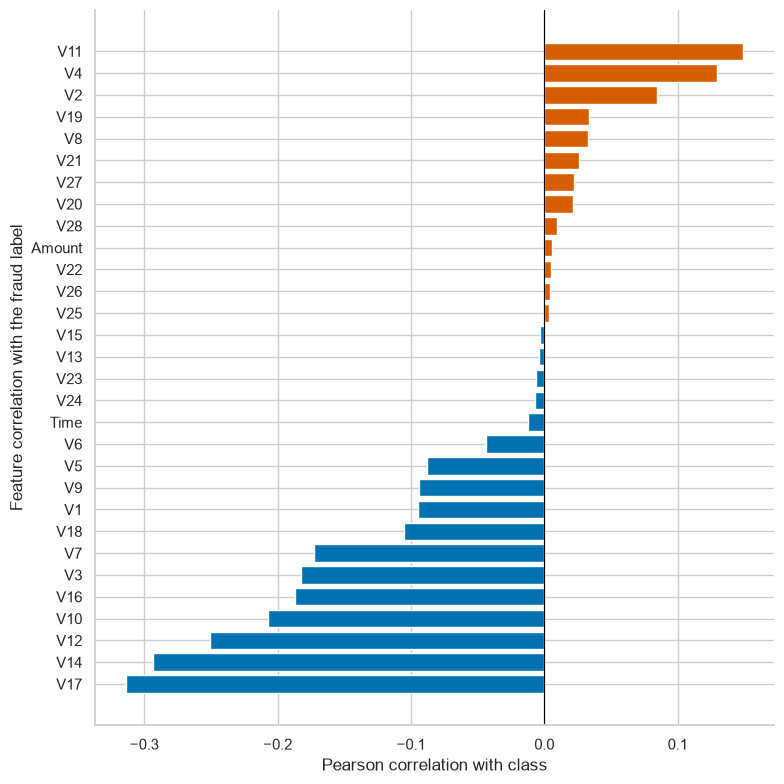

In [87]:
fig, ax = plt.subplots(figsize=(8, 8))
colors = [COLOR_FRAUD if v > 0 else COLOR_LEGIT for v in corr_with_class]
ax.barh(corr_with_class.index, corr_with_class.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson correlation with class")
ax.set_ylabel("Feature correlation with the fraud label")
plt.tight_layout()
plt.show()

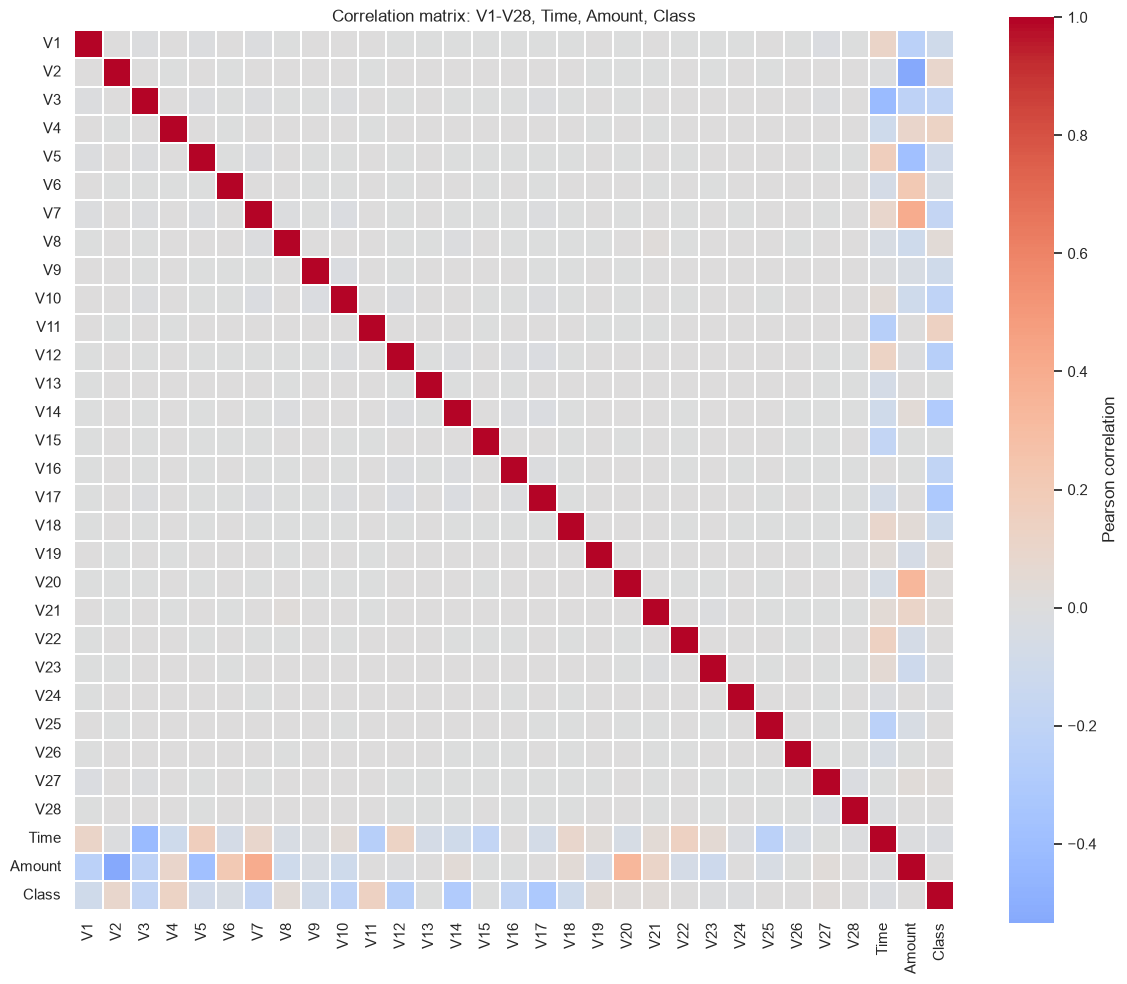

In [88]:
corr_matrix = df[v_cols + ["Time", "Amount", "Class"]].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=True,
            linewidths=0.3, cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_title("Correlation matrix: V1-V28, Time, Amount, Class")
plt.tight_layout()
plt.show()

**Observation:** The `V` elements are mostly uncorrelated with each other. The heat map is flat except for the `Class` row and column. `Time` and `Amount` show very little correlation with the `V` elements as well.

Against the target, the strongest linear relationships are `V17`, `V14` and `V10`. `Time` and `Amount` barely register, with a correlation of less than 0.02.

## Screening all PCA components by Class

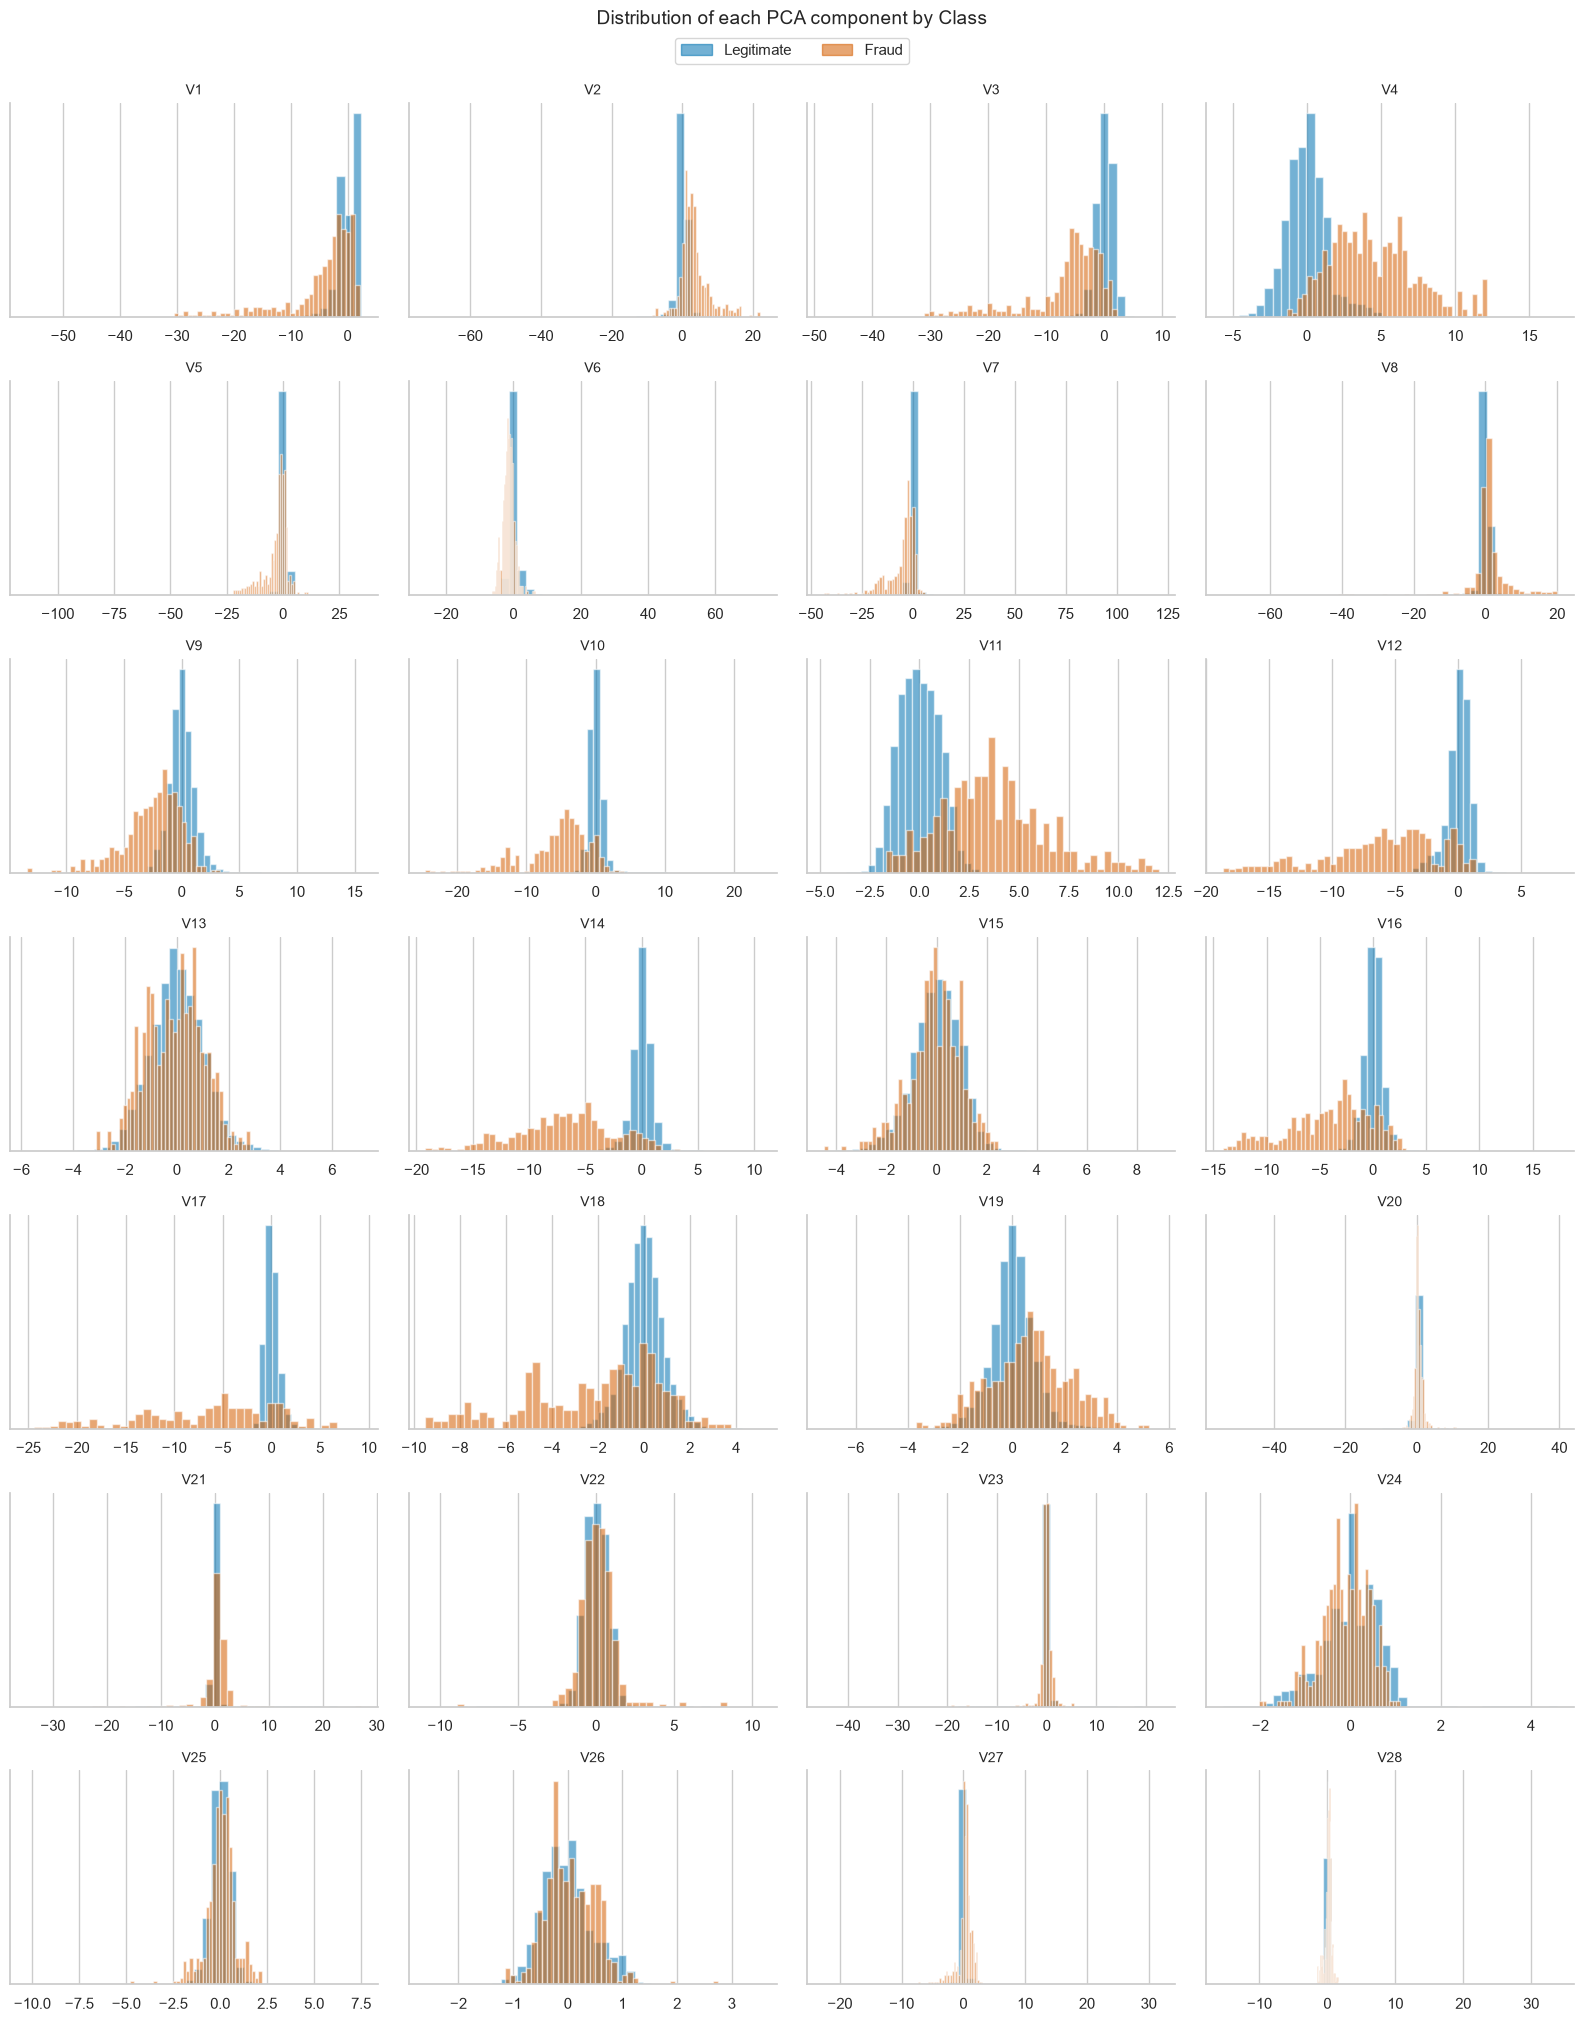

In [89]:
fig, axes = plt.subplots(7, 4, figsize=(16, 20))
for ax, col in zip(axes.flat, v_cols):
    for cls, colour in CLASS_PALETTE.items():
        ax.hist(df.loc[df["Class"] == cls, col], bins=40, density=True,
                alpha=0.55, color=colour)
    ax.set_title(col, fontsize=10)
    ax.set_yticks([])

# One shared legend for the whole grid
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=COLOR_LEGIT, alpha=0.55),
                  plt.Rectangle((0, 0), 1, 1, color=COLOR_FRAUD, alpha=0.55)]
fig.legend(legend_handles, ["Legitimate", "Fraud"], loc="upper center",
           ncol=2, bbox_to_anchor=(0.5, 1.0), fontsize=11)
fig.suptitle("Distribution of each PCA component by Class",
             y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

From looking histograms we can see that most components show a lot of overlap between the two classes, but a few of the components like `V17`, `V14` and `V12` show the fraud distribution visibly shifted away from the legitimate one. This give an idea of which anonymised components are likely to matter the most.

# Examinining the most discriminative features

In [90]:
abs_corr = corr_with_class.abs().sort_values(ascending=False)
top_features = abs_corr.head(6).index.tolist()
print(top_features)

['V17', 'V14', 'V12', 'V10', 'V16', 'V3']


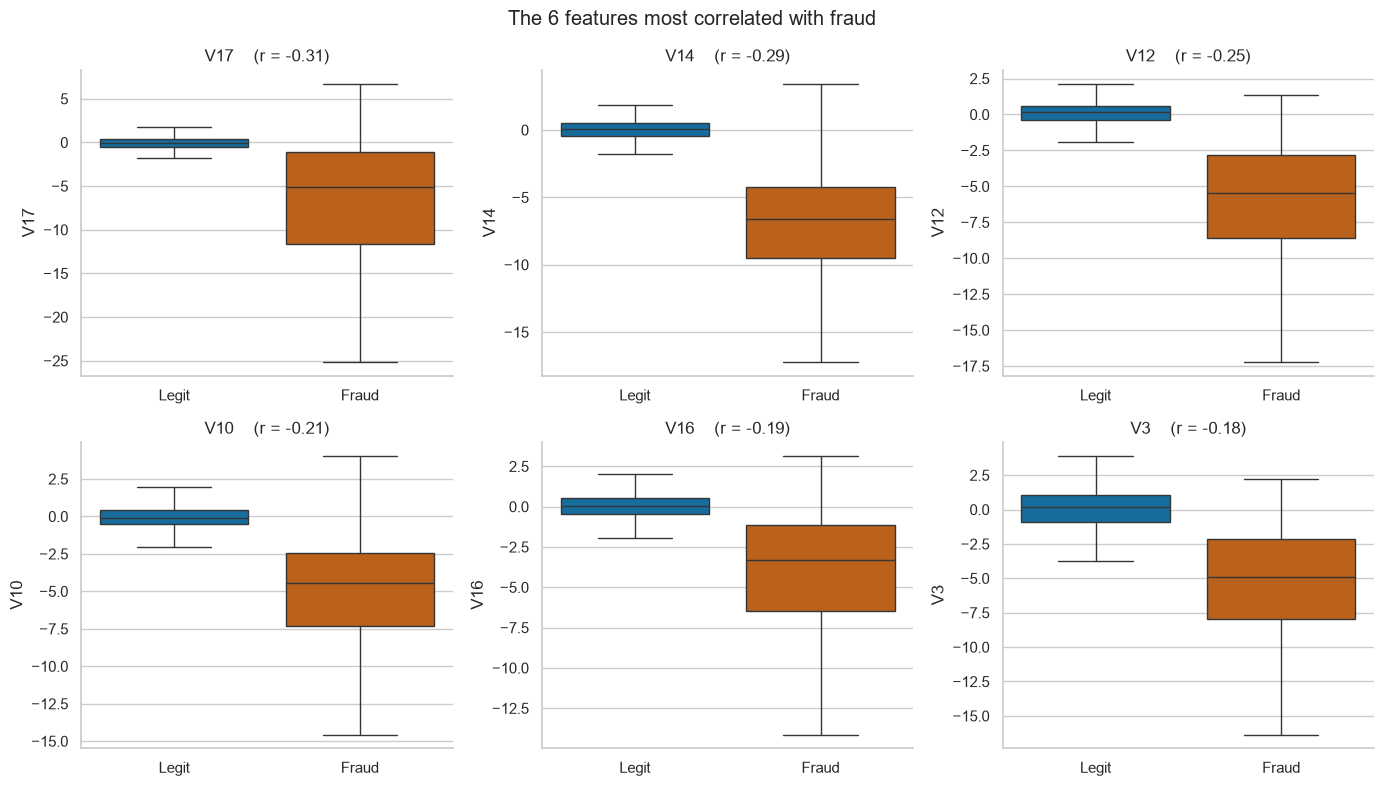

In [91]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, top_features):
    sns.boxplot(data=df, x="Class", y=col, hue="Class", palette=CLASS_PALETTE,
                showfliers=False, legend=False, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Legit", "Fraud"])
    ax.set_xlabel("")
    ax.set_title(f"{col}    (r = {corr_with_class[col]:.2f})")

fig.suptitle("The 6 features most correlated with fraud")
plt.tight_layout()
plt.show()

For all six features the fraud class's median and interquartile range sit clearly apart from the legitimate class's. This is clear visual confirmation that a classifier has a real signal to work with, even before modelling happens.

**Note:** Because the `V` components are anonymised PCA components, we can figure out that they seperate the classes, but we are unable to say why. A component with a large negative value for fraud can not be tracked back to a specific real-world attribute such as "location of transaction" or "rate of expenditure". That would only be possible with a dataset that isn't anonymised. Any feature importance analysis performed is therefore useful for building a good classifier, but limited when it comes to finding business explanations.

## Key findings

**The dataset is extremely imbalanced.**
after removing duplicates, fraud accounts for just 473 out of 283,726 transactions. That's 0.167%, roughly 1 in 600. The implications of this are:

- Accuracy is meaningless. A model that predicts "legitimate" for every row will score 99.8% while catching no fraud. The model will instead be evaluated with precision, recall, F1 and AUPRC.
- The train/test split must be stratified on `Class` so that the test set will have enough fraud cases to measure against.
- The imbalance needs direct treatment. If left untreated, most classifiers would optimise for overall accuracy, this would effectively ignore the minority class (fraud).

**Data quality is high.**
There are no missing values. 1,081 duplicate rows were found and 19 of these were fraud. They were dropped after checking their class balance, leaving 283,726 rows and 31 columns. All features are numeric.

**`Time` and `Amount` need scaling.**
`V1`-`V28` are already centred and on a broadly similar scale, `Time` and `Amount` however were outside the PCA step and would dominate distance and gradient based models, so StandardScaler will be applied.

**Fraud amounts are typically smaller.**
The median amount for fraud is 9.82 vs 22 for legitimate transactions. Even though both classes are heavily right skewed, `Amount` on its own is a weak discriminator (r = 0.006).

**Fraud has a non-linear time-of-day pattern.**
The fraud rates spike overnight and peak around 02:00 am, when the volume of legitimate transactions is at its lowest. Linear correlation with `Time` is negligible, but the overnight pattern is a real non-linear signal so `Time` is kept and scaled rather than dropped. A cyclical encoding of the hour is a possible refinement for later.

**A few PCA components carry most of the signal.**
The `V` components aren't correlated to each other. The ones with the strongest correlation to fraud are `V17`, `V14`, `V12`, `V10`, `V16`, `V3`, `V11` and `V4`.  On the other hand, `Time` and `Amount` barely register (|r| < 0.02). All 28 components are kept. There is no multicollinearity reason to drop any of them and no manual selection is done.

**Anonymised components.**
Since the PCA components (`V1`-`V28`) are anonymised, feature importance can be ranked but, we can't find out why the individual components matter. They can't be translated to business insights.

*Note regarding leakage:* in order to obtain a comprehensive picture, this EDA was performed on the entire de-duplicated dataset. The previously-mentioned feature signal observations are simply directional. No information from the test fold reaches the model because the modelling section re-derives them on the training fold, and every fitted transformation (scaling included) lives inside a `Pipeline` fit on training data, so no information from the test fold reaches the model.

## Train/Test Split

In [92]:
# Create features and targe column
X = df[FEATURE_COLS]
y = df[TARGET_COL]

In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_SEED
)

# Print train and test data shapes
X_train.shape, X_test.shape

((226980, 30), (56746, 30))

In [94]:
# Stratification check
pd.DataFrame({
    "train": y_train.value_counts(normalize=True),
    "test": y_test.value_counts(normalize=True)
}).mul(100).round(3)

,train,test
Class,,
0,99.833,99.833
1,0.167,0.167


## Baseline Model: Logistic Regression
A linear model is a good starting point because it is fast, simple and does not require much tuning. Its performance gives us a baseline that the later models, such as Random Forest, XGBoost and neural networks should aim to improve on.

The model is evaluated on the held-out test set using the same evaluation helper that the other models will use. This ensures that the test results can be compared fairly.

For now, the model is trained without any class balance correction. `class_weight="balanced"` will be introduced later to investigate how handling class imbalance affects the model's performance compared with the baseline.

In [95]:
baseline_model = build_model_pipeline(
    LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_SEED
    )
)

baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Time','Amount','V1',...,'V26','V27','V28']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scale', ...), ('pca', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names

In [96]:
baseline_metrics = evaluate_classifier(baseline_model, X_test, y_test)
pd.Series(baseline_metrics)

precision            0.879310
recall               0.536842
f1                   0.666667
auprc                0.742974
roc_auc              0.968538
tn               56644.000000
fp                   7.000000
fn                  44.000000
tp                  51.000000
expected_cost     4435.000000
dtype: float64

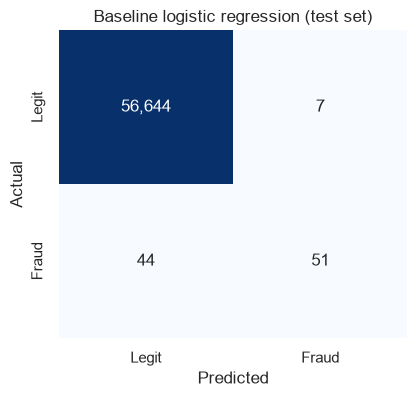

In [97]:
plot_confusion_matrix(
    y_test,
    baseline_model.predict(X_test),
    title="Baseline logistic regression (test set)"
)

plt.show()

### Why accuracy is the wrong metric

In [98]:
always_legit = np.zeros_like(y_test)

acc_naive = accuracy_score(y_test, always_legit)
acc_baseline = accuracy_score(y_test, baseline_model.predict(X_test))

print(f"'Always legit' accuracy:    {acc_naive:.4%}" )
print(f"Baseline model accuracy:    {acc_baseline:.4%}")

'Always legit' accuracy:    99.8326%
Baseline model accuracy:    99.9101%


### Baseline model results
| Metric        |        Value |
|---------------|-------------:|
| Precision     |     0.879310 |
| Recall        |     0.536842 |
| F1            |     0.666667 |
| AUPRC         |     0.742974 |
| ROC-AUC       |     0.968538 |
| tn            | 56644.000000 |
| fp            |    7.0000000 |
| fn            |   44.0000000 |
| tp            |   51.0000000 |
| expected_cost | 4435.0000000 |



On the test set, there were **95 fraud cases out of 56,746 transactions**. The model correctly identified **51 fraud cases**, missed **44** and incorrectly flagged **7 legitimate transactions** as fraud.

**Accuracy is not a useful metric here.** An "always legitimate" model would achieve 99.83% accuracy, while the baseline achieves 99.91%. Despite the small difference, the two models are very different: the first catches no fraud, while the baseline catches more than half of the fraud cases. For this reason, accuracy will not be used to compare the models going forward.

**Precision is high, but recall is relatively low.** When the baseline flags a transaction as fraudulent, it is correct **88% of the time**. However, it only identifies **54% of all fraud cases**. Since missing a fraudulent transaction can be more costly than incorrectly flagging a legitimate one, **recall and AUPRC will be the main metrics used to compare the later models**.

The baseline therefore provides the **performance level that the later models should aim to improve on**, particularly in terms of recall and AUPRC.

### Random Forest

A Random Forest is a machine learning model made up of many decision trees. Each tree is trained using a random sample of the data and a random selection of features when making splits. Combining the predictions from many trees helps reduce the risk of relying too heavily on any single tree.

Random Forests make decisions using feature thresholds, which means they do not require features to be on the same scale. Therefore, the `StandardScaler` in the pipeline is not necessary for this model, but keeping it does not cause any problems.

`RandomizedSearchCV` samples 30 combinations of `n_estimators`, `max_depth`, `min_samples_leaf` and `max_features` using 3-fold cross-validation. Candidates are scored on **average precision (AUPRC)** rather than accuracy, since AUPRC is the appropriate metric for this imbalanced problem.

In [99]:
# Instantiate random forest model
rf_pipeline = build_model_pipeline(
    RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1)
)